# 🫁 Clasificación de Neumonía — SIN Data Augmentation
## Experimento de Comparación `WithoutDataAugmentation`

---

## 🎯 Propósito de este notebook

Este notebook es **idéntico** al notebook principal `Pneumonia_Clasificacion_CNN.ipynb`, con una **única diferencia intencional**:

| Aspecto | Notebook Principal | **Este Notebook** |
|---|---|---|
| Data Augmentation | ✅ `rotation_range`, `flip`, `zoom`, etc. | ❌ Solo `rescale=1./255` |
| Resto de parámetros | Igual | **Igual** |
| Arquitectura | Igual | **Igual** |
| Épocas | Igual | **Igual** |
| Callbacks | Igual | **Igual** |

## 📊 ¿Qué esperamos observar en la comparación?

| Métrica | Con Augmentation | Sin Augmentation (expected) |
|---------|-----------------|-----------------------------|
| Train Accuracy | Alta | **Más alta** |
| Val Accuracy | Alta | **Más baja** |
| Test Accuracy | Buena | **Peor** |
| Brecha Train/Val | Pequeña | **Mayor** (overfitting) |
| AUC | Alto | **Más bajo** |

> **Sin augmentation**, el modelo tiende a **sobreajustar (overfitting)** porque ve las mismas imágenes exactamente en cada época, memorizándolas en lugar de aprender características generalizables.

---

# 📦 PASO 1: Importaciones

Exactamente las mismas importaciones que en el notebook principal.

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import json
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from shutil import copyfile
from tensorflow.keras.layers import (
    Conv2D, Add, MaxPooling2D, Dense, BatchNormalization,
    Input, GlobalAveragePooling2D, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Misma semilla que el notebook principal → resultados reproducibles y comparables
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ─────────────────────────────────────────────────────────
# IDENTIFICADOR DE EXPERIMENTO
# ─────────────────────────────────────────────────────────
EXPERIMENT_NAME = "SinAugmentation"
print(f'🔬 Experimento: {EXPERIMENT_NAME}')
print(f'   Data Augmentation: ❌ DESACTIVADO')
print(f'   Solo rescale=1./255 en el generador de train')
print(f'   TensorFlow: {tf.__version__}')

🔬 Experimento: SinAugmentation
   Data Augmentation: ❌ DESACTIVADO
   Solo rescale=1./255 en el generador de train
   TensorFlow: 2.21.0


# 📂 PASO 2: Rutas del Dataset

El dataset es el **mismo** que en el notebook principal.  
Apuntamos al directorio `chest_xray` dentro de `Pneumonia_EasterWeek/`.

In [2]:
# El dataset está en la carpeta PADRE de este notebook
# (Pneumonia_EasterWeek/chest_xray)
BASE_DIR = os.path.join(os.path.dirname(os.getcwd()), 'chest_xray')

# Si ejecutas desde otra ruta, ajusta aquí:
# BASE_DIR = r'C:\ruta\a\chest_xray'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

CLASS_NAMES = ['NORMAL', 'PNEUMONIA']

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    status = '✅' if os.path.exists(d) else '❌ NO EXISTE'
    print(f'{status} {d}')

✅ c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\Pneumonia_EasterWeek\chest_xray\train
✅ c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\Pneumonia_EasterWeek\chest_xray\val
✅ c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\Pneumonia_EasterWeek\chest_xray\test


# 📊 PASO 3: Conteo y Distribución del Dataset

In [3]:
def count_images(base_dir, class_names):
    counts = {}
    for cls in class_names:
        path = os.path.join(base_dir, cls)
        if os.path.exists(path):
            imgs = [f for f in os.listdir(path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            counts[cls] = len(imgs)
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR, CLASS_NAMES)
test_counts  = count_images(TEST_DIR,  CLASS_NAMES)

print('DISTRIBUCIÓN DEL DATASET')
print(f"Train NORMAL:    {train_counts.get('NORMAL', 0)}")
print(f"Train PNEUMONIA: {train_counts.get('PNEUMONIA', 0)}")
print(f"Test NORMAL:     {test_counts.get('NORMAL', 0)}")
print(f"Test PNEUMONIA:  {test_counts.get('PNEUMONIA', 0)}")

fig = px.pie(
    names=CLASS_NAMES,
    values=[train_counts.get(c, 0) for c in CLASS_NAMES],
    title='Distribución de clases - Entrenamiento (Sin Augmentation)',
    color_discrete_sequence=['#2E86AB', '#E84855']
)
fig.show()

# Class weights (igual que en el notebook principal)
n_normal    = train_counts.get('NORMAL', 1)
n_pneumonia = train_counts.get('PNEUMONIA', 1)
total_train = n_normal + n_pneumonia
class_weight = {
    0: total_train / (2 * n_normal),
    1: total_train / (2 * n_pneumonia)
}
print(f'\n⚖️  Class Weights: {class_weight}')

DISTRIBUCIÓN DEL DATASET
Train NORMAL:    1341
Train PNEUMONIA: 3875
Test NORMAL:     234
Test PNEUMONIA:  390



⚖️  Class Weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


# 📦 PASO 4: Partición de Validación

Usamos la **misma carpeta de validación** creada por el notebook principal  
(`chest_xray_new_val`), garantizando que los conjuntos sean idénticos para una comparación justa.

In [4]:
def split_data_from_train(train_dir, new_val_dir, class_names,
                           val_split=0.1, seed=42):
    random.seed(seed)
    for cls in class_names:
        src_dir = os.path.join(train_dir, cls)
        dst_dir = os.path.join(new_val_dir, cls)
        os.makedirs(dst_dir, exist_ok=True)
        files = [
            f for f in os.listdir(src_dir)
            if os.path.getsize(os.path.join(src_dir, f)) > 0
            and f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        shuffled = random.sample(files, len(files))
        n_val    = int(val_split * len(shuffled))
        print(f'  {cls}: {len(files)} total → {n_val} para validación')
        for fname in shuffled[:n_val]:
            copyfile(os.path.join(src_dir, fname),
                     os.path.join(dst_dir, fname))

# Reutilizar la misma carpeta de validación que el notebook principal
NEW_VAL_DIR = os.path.join(os.path.dirname(BASE_DIR), 'chest_xray_new_val')

if not os.path.exists(NEW_VAL_DIR):
    print('Creando partición de validación (10% de train)...')
    split_data_from_train(TRAIN_DIR, NEW_VAL_DIR, CLASS_NAMES, val_split=0.10)
    print('✅ Partición creada.')
else:
    print('✅ Reutilizando partición de validación del notebook principal.')

EFFECTIVE_VAL_DIR = NEW_VAL_DIR

val_counts = count_images(EFFECTIVE_VAL_DIR, CLASS_NAMES)
print(f"\nVal NORMAL:     {val_counts.get('NORMAL', 0)}")
print(f"Val PNEUMONIA:  {val_counts.get('PNEUMONIA', 0)}")

✅ Reutilizando partición de validación del notebook principal.

Val NORMAL:     134
Val PNEUMONIA:  387


# 🔄 PASO 5: Generadores de Datos — ⚠️ SIN Data Augmentation

## Diferencia clave con el notebook principal

```python
# ✅ Notebook principal (CON augmentation):
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,      # ← ELIMINADO en este notebook
    width_shift_range=0.2,  # ← ELIMINADO
    height_shift_range=0.2, # ← ELIMINADO
    horizontal_flip=True,   # ← ELIMINADO
    zoom_range=0.2,         # ← ELIMINADO
    shear_range=0.1,        # ← ELIMINADO
    fill_mode='nearest'     # ← ELIMINADO
)

# ❌ Este notebook (SIN augmentation):
train_gen = ImageDataGenerator(
    rescale=1./255          # ← Solo normalización
)
```

## ¿Qué consecuencias tiene esto?

- El modelo ve **exactamente las mismas imágenes** en cada época
- Puede **memorizar** las imágenes de entrenamiento
- Esperamos ver **mayor overfitting**: train accuracy >> val accuracy
- La **generalización** al conjunto de test será probablemente peor

In [5]:
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

# ════════════════════════════════════════════════════════
# ⚠️  GENERADOR DE TRAIN: SOLO rescale, SIN augmentation
# Esta es la ÚNICA diferencia con el notebook principal
# ════════════════════════════════════════════════════════
train_gen = ImageDataGenerator(
    rescale=1./255  # ← Único parámetro (sin rotation, flip, zoom, etc.)
)

# Validación y test: igual que el notebook principal (solo rescale)
validation_gen = ImageDataGenerator(rescale=1./255)
test_gen       = ImageDataGenerator(rescale=1./255)

# Iteradores
train_generator = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

validation_generator = validation_gen.flow_from_directory(
    EFFECTIVE_VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f'\n📌 EXPERIMENTO: {EXPERIMENT_NAME}')
print(f'   Augmentation en TRAIN: ❌ DESACTIVADO')
print(f'   Índices de clase: {train_generator.class_indices}')
print(f'   Imágenes train:   {train_generator.n}')
print(f'   Imágenes val:     {validation_generator.n}')
print(f'   Imágenes test:    {test_generator.n}')

Found 5216 images belonging to 2 classes.
Found 521 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

📌 EXPERIMENTO: SinAugmentation
   Augmentation en TRAIN: ❌ DESACTIVADO
   Índices de clase: {'NORMAL': 0, 'PNEUMONIA': 1}
   Imágenes train:   5216
   Imágenes val:     521
   Imágenes test:    624


## 🔍 Comparación visual: Con vs Sin Augmentation

Al visualizar un batch del generador de entrenamiento:
- **Notebook principal**: Cada imagen aparece rotada, ampliada, desplazada o volteada
- **Este notebook**: Las imágenes aparecen **sin ninguna transformación geométrica**

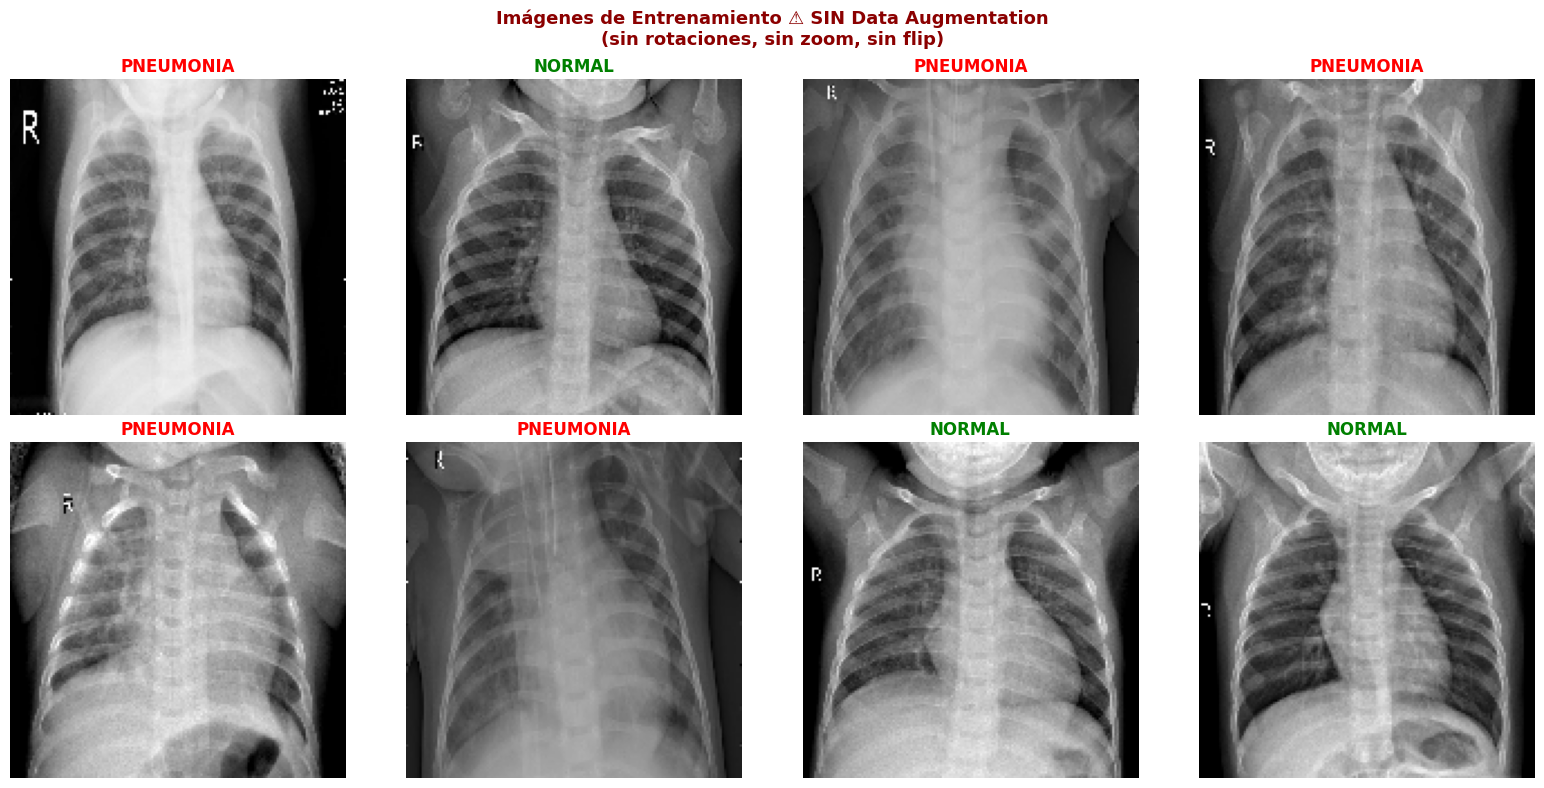

In [6]:
# Visualizar imágenes del generador (sin augmentation)
images, labels = next(train_generator)
labels = labels.astype('int32')

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(min(8, len(images))):
    axes[i].imshow(images[i])
    cls_name = CLASS_NAMES[labels[i]]
    color = 'green' if cls_name == 'NORMAL' else 'red'
    axes[i].set_title(cls_name, color=color, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Imágenes de Entrenamiento ⚠️ SIN Data Augmentation\n'
             '(sin rotaciones, sin zoom, sin flip)',
             fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()

# 🧠 PASO 6: Arquitectura CNN

**Arquitectura idéntica** al notebook principal — la única variable en este experimento es el Data Augmentation.

```
Input (150, 150, 3)
  ↓  Conv2D(32) + BN + ReLU
  ↓  MaxPool → 75×75×32
  ↓  ResBlock(64) → MaxPool → Dropout(0.25)
  ↓  ResBlock(128) → MaxPool → Dropout(0.25)
  ↓  ResBlock(256)
  ↓  GlobalAveragePooling2D
  ↓  Dense(256) + Dropout(0.5)
  ↓  Dense(1, sigmoid)  →  P(PNEUMONIA)
```

In [7]:
def residual_block(x, filters, kernel_size=3):
    """
    Bloque residual — idéntico al notebook principal.
    F(x) + x: conexión de salto que facilita el flujo del gradiente.
    """
    shortcut = x
    x = Conv2D(filters, kernel_size, padding='same', activation=None)(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = Conv2D(filters, kernel_size, padding='same', activation=None)(x)
    x = BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    x = tf.keras.layers.Activation('relu')(x)
    return x


def build_pneumonia_cnn(input_shape=(150, 150, 3)):
    """
    Modelo CNN — idéntico al notebook principal.
    Se mantiene igual para que la comparación sea válida.
    """
    inputs = Input(shape=input_shape, name='input_radiografia')

    x = Conv2D(32, (3, 3), padding='same', name='conv1')(inputs)
    x = BatchNormalization(name='bn1')(x)
    x = tf.keras.layers.Activation('relu', name='relu1')(x)
    x = MaxPooling2D((2, 2), name='pool1')(x)

    x = residual_block(x, filters=64)
    x = MaxPooling2D((2, 2), name='pool2')(x)
    x = Dropout(0.25, name='dropout1')(x)

    x = residual_block(x, filters=128)
    x = MaxPooling2D((2, 2), name='pool3')(x)
    x = Dropout(0.25, name='dropout2')(x)

    x = residual_block(x, filters=256)

    x = GlobalAveragePooling2D(name='gap')(x)
    x = Dense(256, activation='relu', name='dense1')(x)
    x = Dropout(0.5, name='dropout3')(x)
    outputs = Dense(1, activation='sigmoid', name='output_pneumonia')(x)

    return Model(inputs=inputs, outputs=outputs,
                 name=f'PneumoniaCNN_{EXPERIMENT_NAME}')


model = build_pneumonia_cnn(input_shape=IMG_SIZE + (3,))
model.summary()
print(f'\n📌 Parámetros totales: {model.count_params():,}')

Model: "PneumoniaCNN_SinAugmentation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_radiografia   │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 150, 150,  │        896 │ input_radiografi… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 150, 150,  │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 150, 150,  │          0 │ bn1[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 75, 75,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 75, 75,    │     18,496 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 75,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 75, 75,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 75, 75,    │      2,112 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 75, 75,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 37, 37,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 37, 37,    │          0 │ pool2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 37, 37,    │     73,856 │ dropout1[0][0]  

 Total params: 1,278,017 (4.88 MB)

 Trainable params: 1,275,265 (4.86 MB)

 Non-trainable params: 2,752 (10.75 KB)


📌 Parámetros totales: 1,278,017


# ⚙️ PASO 7: Compilación — Idéntica al notebook principal

In [8]:
LEARNING_RATE = 0.001

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)
print('✅ Modelo compilado')
print(f'   Optimizador: Adam (lr={LEARNING_RATE})')
print(f'   Experimento: {EXPERIMENT_NAME}')

✅ Modelo compilado
   Optimizador: Adam (lr=0.001)
   Experimento: SinAugmentation


# 📞 PASO 8: Callbacks — Idénticos al notebook principal

In [9]:
def lr_schedule(epoch, lr):
    """Reduce LR un 10% cada 5 épocas — igual que en perrosygatos.ipynb"""
    if epoch > 0 and epoch % 5 == 0:
        return lr * 0.9
    return lr

callbacks = [
    LearningRateScheduler(lr_schedule, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1)
]
print('✅ Callbacks configurados (idénticos al notebook principal)')

✅ Callbacks configurados (idénticos al notebook principal)


# 🏋️ PASO 9: Entrenamiento — ⚠️ Sin Data Augmentation

El entrenamiento es idéntico al notebook principal:
- Mismas épocas máximas
- Mismos `steps_per_epoch`
- Mismo `class_weight`

La diferencia en los resultados se debe **únicamente** a la ausencia de augmentation.

In [10]:
EPOCHS = 30

train_counts_final = count_images(TRAIN_DIR, CLASS_NAMES)
val_counts_final   = count_images(EFFECTIVE_VAL_DIR, CLASS_NAMES)

steps_per_epoch  = int(np.ceil(sum(train_counts_final.values()) / BATCH_SIZE))
validation_steps = int(np.ceil(sum(val_counts_final.values()) / BATCH_SIZE))

print(f'📌 Experimento: {EXPERIMENT_NAME}')
print(f'   Data Augmentation: ❌ DESACTIVADO')
print(f'   Épocas máx: {EPOCHS}')
print(f'   Steps/época: {steps_per_epoch}')
print(f'   Class weights: {class_weight}')
print('\nIniciando entrenamiento...')
print('='*60)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Entrenamiento completado!')

📌 Experimento: SinAugmentation
   Data Augmentation: ❌ DESACTIVADO
   Épocas máx: 30
   Steps/época: 163
   Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}

Iniciando entrenamiento...

Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 451ms/step - accuracy: 0.8865 - auc: 0.9566 - loss: 0.2622 - val_accuracy: 0.7428 - val_auc: 0.5000 - val_loss: 4.5475 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 71s 436ms/step - accuracy: 0.9350 - auc: 0.9820 - loss: 0.1644 - val_accuracy: 0.7428 - val_auc: 0.5000 - val_loss: 4.7129 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 422ms/step - accuracy: 0.9379 - auc: 0.9831 - loss: 0.1570 - val_accuracy: 0.7754 - val_auc: 0.8941 - val_loss: 0.8587 - learning_rate: 0.0010



# 📈 PASO 10: Curvas de Entrenamiento

## ¿Qué buscar aquí vs el notebook principal?

### Señales de Overfitting (esperadas sin augmentation)
- **Train Loss** sigue bajando mientras **Val Loss** sube
- **Train Accuracy** alta (>95%) mientras **Val Accuracy** se estanca o baja
- La brecha entre curvas de train y val crece con las épocas

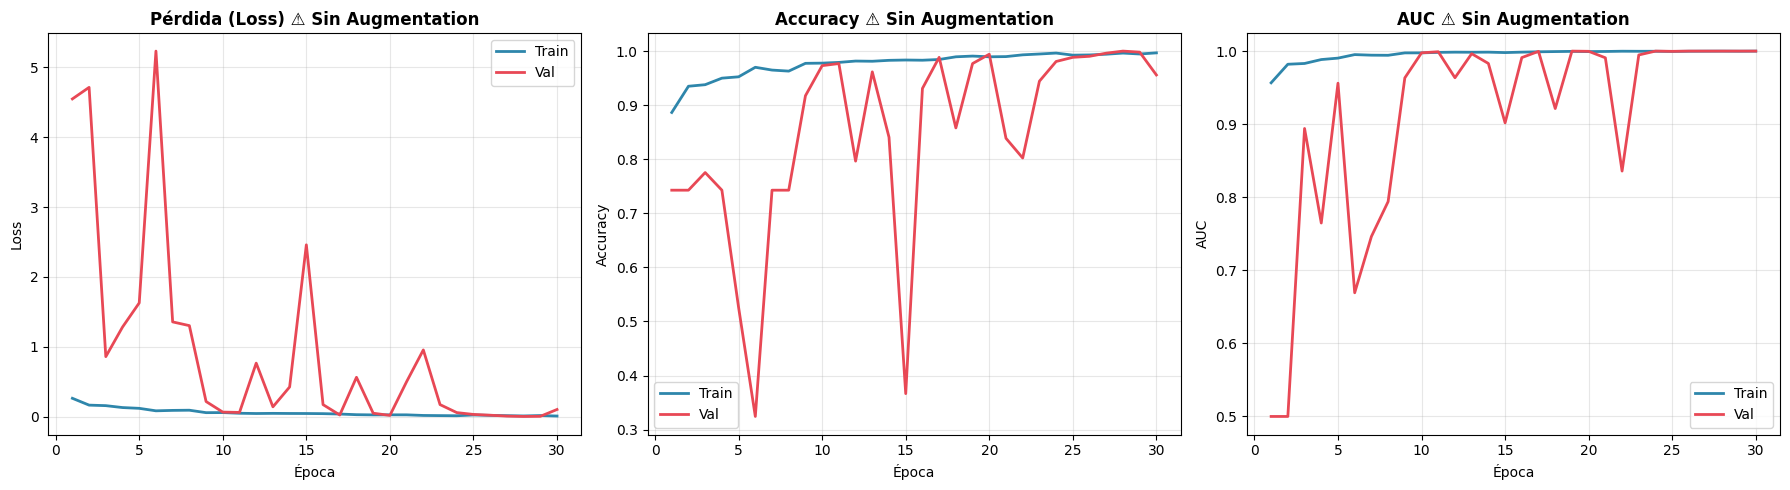

In [11]:
def plot_training_history(history, title_suffix=''):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(history.history['loss']) + 1)

    # Loss
    axes[0].plot(epochs_range, history.history['loss'],
                 label='Train', color='#2E86AB', linewidth=2)
    axes[0].plot(epochs_range, history.history['val_loss'],
                 label='Val', color='#E84855', linewidth=2)
    axes[0].set_title(f'Pérdida (Loss) {title_suffix}', fontweight='bold')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs_range, history.history['accuracy'],
                 label='Train', color='#2E86AB', linewidth=2)
    axes[1].plot(epochs_range, history.history['val_accuracy'],
                 label='Val', color='#E84855', linewidth=2)
    axes[1].set_title(f'Accuracy {title_suffix}', fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # AUC
    if 'auc' in history.history:
        axes[2].plot(epochs_range, history.history['auc'],
                     label='Train', color='#2E86AB', linewidth=2)
        axes[2].plot(epochs_range, history.history['val_auc'],
                     label='Val', color='#E84855', linewidth=2)
        axes[2].set_title(f'AUC {title_suffix}', fontweight='bold')
        axes[2].set_xlabel('Época')
        axes[2].set_ylabel('AUC')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history, title_suffix='⚠️ Sin Augmentation')

# 🎯 PASO 11: Evaluación en Test

Evaluando [SinAugmentation] en conjunto de test...
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.7179 - auc: 0.7453 - loss: 2.0960

RESULTADOS EN TEST — SinAugmentation
  loss: 2.0960
  compile_metrics: 0.7179
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step


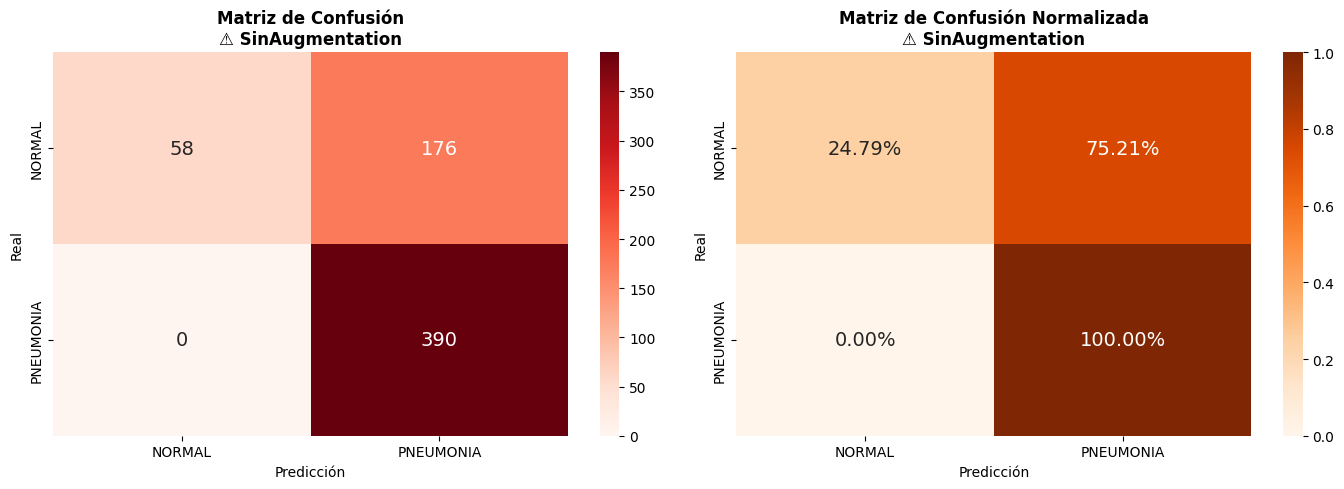


REPORTE DETALLADO
              precision    recall  f1-score   support

      NORMAL       1.00      0.25      0.40       234
   PNEUMONIA       0.69      1.00      0.82       390

    accuracy                           0.72       624
   macro avg       0.84      0.62      0.61       624
weighted avg       0.81      0.72      0.66       624


MÉTRICAS MÉDICAS [SinAugmentation]
  TP=390  TN=58  FP=176  FN=0
  Sensibilidad:  100.00%
  Especificidad: 24.79%
  Precisión:     68.90%


In [12]:
print(f'Evaluando [{EXPERIMENT_NAME}] en conjunto de test...')
test_generator.reset()
test_results = model.evaluate(test_generator, verbose=1)

print('\n' + '='*55)
print(f'RESULTADOS EN TEST — {EXPERIMENT_NAME}')
print('='*55)
for name, val in zip(model.metrics_names, test_results):
    print(f'  {name}: {val:.4f}')

# Predicciones
test_generator.reset()
y_pred_proba = model.predict(test_generator, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_title(f'Matriz de Confusión\n⚠️ {EXPERIMENT_NAME}',
                  fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], annot_kws={'size': 14})
axes[1].set_title(f'Matriz de Confusión Normalizada\n⚠️ {EXPERIMENT_NAME}',
                  fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

print('\n' + '='*55)
print('REPORTE DETALLADO')
print('='*55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

tn, fp, fn, tp = cm.ravel()
sensibilidad  = tp / (tp + fn)
especificidad = tn / (tn + fp)
precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f'\nMÉTRICAS MÉDICAS [{EXPERIMENT_NAME}]')
print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')
print(f'  Sensibilidad:  {sensibilidad:.2%}')
print(f'  Especificidad: {especificidad:.2%}')
print(f'  Precisión:     {precision_val:.2%}')

# 💾 PASO 12: Guardar Modelo e Historial

In [13]:
MODEL_PATH   = f'pneumonia_cnn_{EXPERIMENT_NAME}.keras'
HISTORY_PATH = f'history_{EXPERIMENT_NAME}.json'

model.save(MODEL_PATH)
print(f'✅ Modelo guardado: {MODEL_PATH}')

history_dict = {k: [float(v) for v in vals]
                for k, vals in history.history.items()}
with open(HISTORY_PATH, 'w') as f:
    json.dump(history_dict, f, indent=2)
print(f'✅ Historial guardado: {HISTORY_PATH}')

✅ Modelo guardado: pneumonia_cnn_SinAugmentation.keras
✅ Historial guardado: history_SinAugmentation.json


# 📊 PASO 13: Comparación Visual — Con vs Sin Augmentation

Esta celda carga el historial del **notebook principal** (Con Augmentation) y lo grafica lado a lado con el historial de este experimento (Sin Augmentation).

> **Prerequisito**: El notebook principal debe haberse ejecutado primero y haber guardado `training_history.json`.

✅ Historial CON augmentation cargado.


C:\Users\Rago\AppData\Local\Temp\ipykernel_39124\2071909262.py:55: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Rago\AppData\Local\Temp\ipykernel_39124\2071909262.py:55: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Rago\Documents\Development\redes_neuronales\Redes-Neuronales\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


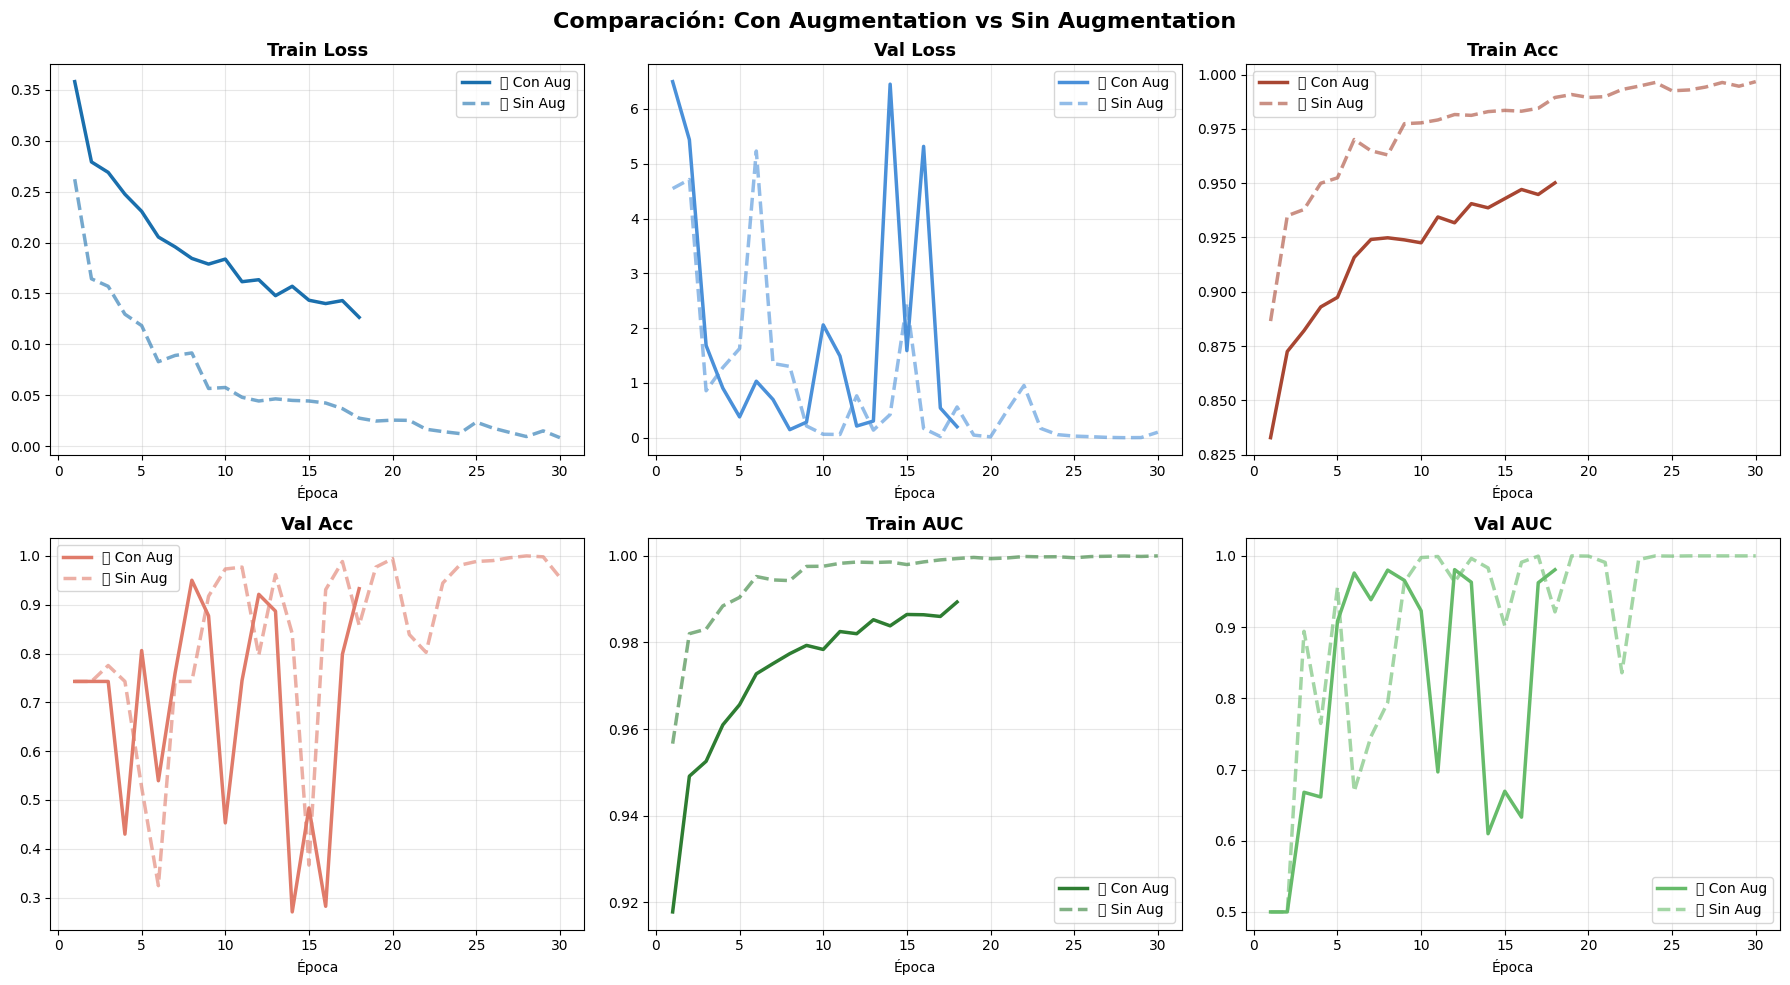

In [14]:
# ── Intentar cargar el historial del notebook CON augmentation ──
MAIN_HISTORY_PATH = os.path.join('..', 'training_history.json')

if os.path.exists(MAIN_HISTORY_PATH):
    with open(MAIN_HISTORY_PATH, 'r') as f:
        history_con = json.load(f)
    print('✅ Historial CON augmentation cargado.')
    has_main = True
else:
    print('⚠️  No se encontró training_history.json del notebook principal.')
    print('   Ejecuta primero Pneumonia_Clasificacion_CNN.ipynb y vuelve a esta celda.')
    has_main = False

history_sin = history.history  # Este experimento

if has_main:
    metrics_to_compare = ['loss', 'val_loss', 'accuracy', 'val_accuracy', 'auc', 'val_auc']
    labels_map = {
        'loss':         ('Train Loss',     '#1a6fad'),
        'val_loss':     ('Val Loss',       '#4a90d9'),
        'accuracy':     ('Train Acc',      '#a84632'),
        'val_accuracy': ('Val Acc',        '#e07b6a'),
        'auc':          ('Train AUC',      '#2e7d32'),
        'val_auc':      ('Val AUC',        '#66bb6a'),
    }

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, metric in enumerate(metrics_to_compare):
        ax = axes[idx]
        label_text, color = labels_map[metric]

        # CON Augmentation
        if metric in history_con:
            vals_con = history_con[metric]
            ax.plot(range(1, len(vals_con)+1), vals_con,
                    linestyle='-', linewidth=2.5, color=color,
                    label=f'✅ Con Aug')

        # SIN Augmentation
        if metric in history_sin:
            vals_sin = history_sin[metric]
            ax.plot(range(1, len(vals_sin)+1), vals_sin,
                    linestyle='--', linewidth=2.5, color=color,
                    alpha=0.6, label=f'❌ Sin Aug')

        ax.set_title(label_text, fontsize=13, fontweight='bold')
        ax.set_xlabel('Época')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Comparación: Con Augmentation vs Sin Augmentation',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 📋 PASO 14: Tabla Comparativa de Resultados Finales

Completa esta tabla manualmente con los valores obtenidos en ambos notebooks.

In [15]:
# Resultados de este experimento
results_sin = dict(zip(model.metrics_names, test_results))

# Intentar cargar resultados del notebook principal
# (si ejecutaste ambos en la misma sesión, podrías importarlos)
print('='*65)
print('TABLA COMPARATIVA DE RESULTADOS EN TEST')
print('='*65)
print(f'{"Métrica":<25} {"✅ Con Augmentation":<22} {"❌ Sin Augmentation"}')
print('-'*65)

for metric in model.metrics_names:
    val_sin = results_sin.get(metric, 'N/A')
    val_sin_str = f'{val_sin:.4f}' if isinstance(val_sin, float) else str(val_sin)
    print(f'{metric:<25} {"(ver notebook principal)":<22} {val_sin_str}')

print('='*65)
print(f'{"Épocas entrenadas":<25} {"(ver notebook principal)":<22} {len(history.history["loss"])}')
print(f'{"Params del modelo":<25} {"(ver notebook principal)":<22} {model.count_params():,}')
print()
print('💡 Interpretación esperada:')
print('  - Sin Augmentation → Train Accuracy MAYOR que Con Augmentation')
print('  - Sin Augmentation → Val/Test Accuracy MENOR (overfitting)')
print('  - Brecha Train/Val MAYOR en Sin Augmentation')
print('  - AUC en test MENOR en Sin Augmentation')

tn2, fp2, fn2, tp2 = cm.ravel()
print()
print(f'  Sensibilidad (Sin Aug): {tp2/(tp2+fn2):.2%}'
      f'  ← Compara con el notebook principal')
print(f'  Especificidad (Sin Aug): {tn2/(tn2+fp2):.2%}')

TABLA COMPARATIVA DE RESULTADOS EN TEST
Métrica                   ✅ Con Augmentation     ❌ Sin Augmentation
-----------------------------------------------------------------
loss                      (ver notebook principal) 2.0960
compile_metrics           (ver notebook principal) 0.7179
Épocas entrenadas         (ver notebook principal) 30
Params del modelo         (ver notebook principal) 1,278,017

💡 Interpretación esperada:
  - Sin Augmentation → Train Accuracy MAYOR que Con Augmentation
  - Sin Augmentation → Val/Test Accuracy MENOR (overfitting)
  - Brecha Train/Val MAYOR en Sin Augmentation
  - AUC en test MENOR en Sin Augmentation

  Sensibilidad (Sin Aug): 100.00%  ← Compara con el notebook principal
  Especificidad (Sin Aug): 24.79%


# 📚 PASO 15: Conclusiones del Experimento

## ¿Por qué Data Augmentation mejora los resultados?

### Sin Data Augmentation (este notebook)

- El modelo ve **exactamente las mismas imágenes** en cada época
- Aprende a reconocer píxeles específicos en posiciones específicas
- **Memoriza** el dataset de entrenamiento → overfitting
- Curvas: Train ↑↑ mientras Val se estanca o deteriora

### Con Data Augmentation (notebook principal)

- El modelo ve **versiones distintas** de cada imagen en cada época
- Aprende características **invariantes** a rotaciones, escalas y traslaciones
- **Generaliza** mejor a datos nuevos
- Curvas: Train y Val convergen más juntas

---

## Analogía para el profesor

> **Sin augmentation**: Como un estudiante que memoriza los ejercicios del libro tal cual están → falla en el examen cuando el mismo concepto se pregunta de otra forma.
>
> **Con augmentation**: Como un estudiante que practica el mismo concepto en distintos contextos → entiende el patrón subyacente y lo aplica en el examen.

---

## Resumen técnico

| Concepto | Sin Augmentation | Con Augmentation |
|----------|-----------------|------------------|
| Variedad de datos | ❌ Baja (siempre los mismos) | ✅ Alta (variaciones por época) |
| Overfitting | ⚠️ Alto | ✅ Reducido |
| Generalización | ❌ Pobre | ✅ Buena |
| Train Accuracy | 🔴 Muy alta | 🟡 Moderada |
| Val/Test Accuracy | 🔴 Más baja | ✅ Más alta |
| Brecha Train/Val | 🔴 Grande | ✅ Pequeña |
| AUC en test | 🔴 Menor | ✅ Mayor |

---

*Dataset: Chest X-Ray Pneumonia — https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia*  
*Comparar con: `../Pneumonia_Clasificacion_CNN.ipynb`*